# Routine Immunization

## Theory

**Routine immunization (RI)** vaccinates a fraction of susceptibles each
tick, effectively moving them directly from S to R (or V).  In a population
with vital dynamics, births continuously replenish S.  RI can keep the
susceptible pool below the epidemic threshold $1/R_0$ and thereby control
or eliminate disease.

The **critical coverage** needed for elimination is:

$$p_c = 1 - \frac{1}{R_0}$$

For R₀ = 5, this is $p_c = 0.8$.  Below $p_c$ the pathogen persists;
above it, transmission is suppressed to extinction.

**Goal:** Run three scenarios — no RI (coverage = 0), partial RI
(coverage = 0.5), and near-elimination RI (coverage = 0.8) — and compare
the infectious time series and cumulative infections across 20 years.

> **Note:** Without age structure, RI here applies to all susceptibles
> each tick, not only infants.  Real RI targets newborns; age-structured
> modelling is required for a faithful representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SEIR as SEIR

# Use the built-in Vaccination intervention from laser.cohorts
try:
    from laser.cohorts.interventions.vaccination import Vaccination
    Campaign.register(Vaccination)
    print("Loaded Vaccination from laser.cohorts.interventions.vaccination")
except ImportError:
    # Fallback: minimal inline Vaccination that moves S → R
    print("Built-in Vaccination not found — using inline fallback")

    class Vaccination(Intervention):
        """Move a binomial-drawn fraction of targeted S individuals into R."""

        @property
        def states(self):
            return []

        @property
        def properties(self):
            return []

        def apply(self, tick, who, where, params, notes):
            coverage = float(params.get("coverage", 0.0))
            target   = where if where is not None else list(range(len(self.model.scenario)))
            S_idx    = self.model.states.get_state_index("S")
            R_idx    = self.model.states.get_state_index("R")
            if S_idx is None or R_idx is None:
                return
            for node in target:
                S_count  = self.model.states[tick + 1][S_idx, node]
                vaccinated = np.random.binomial(S_count, coverage)
                self.model.states[tick + 1][S_idx, node] -= vaccinated
                self.model.states[tick + 1][R_idx, node] += vaccinated

    Campaign.register(Vaccination)

Loaded Vaccination from laser.cohorts.interventions.vaccination


In [2]:
# Shared parameters across all scenarios
N              = 500_000
I0             = 50
CDR            = 20                  # per 1000 per year
r_mortality    = CDR / 1000 / 365
beta           = 0.5
gamma          = 0.1                 # recovery rate (SEIR uses this as r_recovery)
sigma          = 0.2                 # progression rate E→I  (mean latent period = 5 days)
nticks         = 20 * 365
n_nodes        = 1

R0 = beta / gamma
p_critical = 1.0 - 1.0 / R0

print(f"R0              = {R0:.1f}")
print(f"Critical coverage p_c = 1 - 1/R0 = {p_critical:.2f}")

R0              = 5.0
Critical coverage p_c = 1 - 1/R0 = 0.80


In [3]:
def run_seir_with_ri(coverage, N, I0, r_mortality, beta, sigma, gamma, nticks):
    """Run a single-patch SEIR model with vital dynamics and routine immunization.

    Vaccination is applied every tick to susceptibles at the given coverage.
    Uses the built-in Vaccination intervention (or the fallback S→R version).

    Args:
        coverage: Fraction of susceptibles vaccinated per tick.
        N: Initial population size.
        I0: Initial infectious count.
        r_mortality: Daily non-disease mortality rate.
        beta: Transmission rate.
        sigma: Progression rate E→I.
        gamma: Recovery rate.
        nticks: Simulation length in days.

    Returns:
        Fitted model after model.run().
    """
    scenario = grid(M=1, N=1)
    scenario["S"] = N - I0
    scenario["E"] = 0
    scenario["I"] = I0
    scenario["R"] = 0

    params = PropertySet({"nticks": nticks})
    model  = Model(scenario, params)

    # Every-tick RI schedule — "*" means all ticks, "*" means all nodes
    if coverage > 0:
        schedule = [{"who": ["S"], "what": "Vaccination", "when": "*",
                     "where": "*", "parameters": {"coverage": coverage}, "notes": "RI"}]
        campaign = Campaign(model, schedule)
    else:
        campaign = None

    betas         = ValuesMap.from_scalar(beta,  nticks, 1)
    r_recoveries  = ValuesMap.from_scalar(gamma, nticks, 1)
    r_progressions = ValuesMap.from_scalar(sigma, nticks, 1)

    components = [
        SEIR.Susceptible(model),
        SEIR.Exposed(model, r_progression=r_progressions),
        SEIR.Infectious(model, r_recovery=r_recoveries),
        SEIR.Recovered(model),
        NonDiseaseMortality(model, r_mortality=r_mortality),
        ConstantPopBirths(model),
        SEIR.Transmission(model, beta=betas),
    ]
    if campaign is not None:
        # Insert campaign before transmission so vaccinated S don't transmit
        components.insert(-1, campaign)

    model.components = components
    model.run()
    return model


# Run three scenarios
coverages = [0.0, 0.5, 0.8]
models    = {}

for cov in coverages:
    print(f"Running coverage = {cov:.1f} ...")
    models[cov] = run_seir_with_ri(
        cov, N, I0, r_mortality, beta, sigma, gamma, nticks
    )

print("All scenarios complete.")

Running coverage = 0.0 ...
Running coverage = 0.5 ...
Running coverage = 0.8 ...
All scenarios complete.


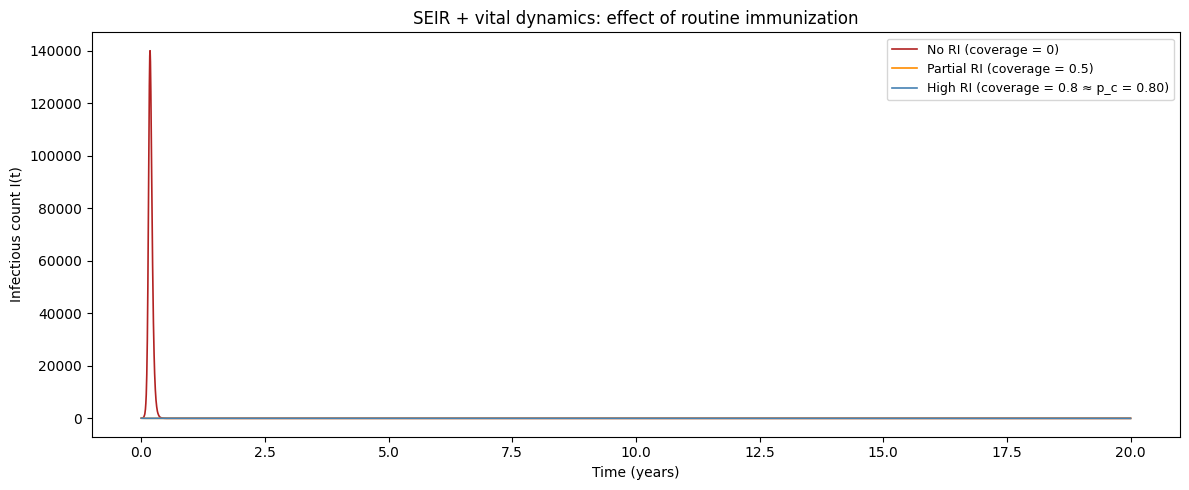

In [4]:
# Plot I(t) for all three coverage scenarios
colors = {0.0: "firebrick", 0.5: "darkorange", 0.8: "steelblue"}
labels = {
    0.0: "No RI (coverage = 0)",
    0.5: "Partial RI (coverage = 0.5)",
    0.8: f"High RI (coverage = 0.8 ≈ p_c = {p_critical:.2f})",
}

t_years = np.arange(nticks + 1) / 365.0

fig, ax = plt.subplots(figsize=(12, 5))
for cov in coverages:
    I_ts = models[cov].states.I[:, 0]
    ax.plot(t_years, I_ts, color=colors[cov], linewidth=1.2, label=labels[cov])

ax.set_xlabel("Time (years)")
ax.set_ylabel("Infectious count I(t)")
ax.set_title("SEIR + vital dynamics: effect of routine immunization")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Coverage 0.0: cumulative infections =    496,202
Coverage 0.5: cumulative infections =         23
Coverage 0.8: cumulative infections =          5


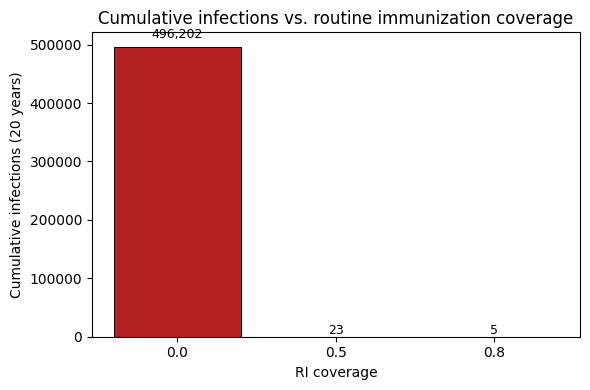

Coverage 0.5: 100.0% reduction vs. no RI
Coverage 0.8: 100.0% reduction vs. no RI


In [5]:
# Compute cumulative infections for each scenario
cumulative = {}
for cov in coverages:
    ni = models[cov].nodes.newly_infectious[:, 0]
    cumulative[cov] = int(ni.sum())
    print(f"Coverage {cov:.1f}: cumulative infections = {cumulative[cov]:>10,}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [str(c) for c in coverages],
    [cumulative[c] for c in coverages],
    color=[colors[c] for c in coverages],
    edgecolor="black",
    linewidth=0.7,
)
for bar, cov in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{cumulative[cov]:,}",
            ha="center", va="bottom", fontsize=9)

ax.set_xlabel("RI coverage")
ax.set_ylabel("Cumulative infections (20 years)")
ax.set_title("Cumulative infections vs. routine immunization coverage")
plt.tight_layout()
plt.show()

# Reduction relative to no-RI baseline
baseline = cumulative[0.0]
for cov in coverages[1:]:
    reduction = 100.0 * (1.0 - cumulative[cov] / baseline)
    print(f"Coverage {cov:.1f}: {reduction:.1f}% reduction vs. no RI")

## Limitation: no age structure

In this notebook, the Vaccination intervention applies to **all
susceptibles** on every tick — regardless of age.  In reality, routine
immunization programs target **infants** at a specific age (e.g., 9 months
for measles).  The effective protection in the population therefore depends
on the age structure: only the small fraction of the susceptible pool that
is currently at the target age receives the vaccine.

The consequence here is that the modelled RI is *more efficient* than real
RI: vaccinating adults who have already survived childhood infection adds
little epidemiological benefit in practice.

A faithful representation of routine immunization requires an
age-structured model.  That capability is beyond the current scope of
laser.cohorts, which does not carry individual ages.  An age-stratified
compartmental model (e.g., multiple cohort bands) or an agent-based model
would be needed.